In [ ]:
from tradepy.data.loader import load_future
from tradepy.config.config import load_config, load_symbols, load_feature_config, load_exclude_config
from tradepy.data.loader import load_specs
from tradepy.data.cleaner import add_trading_date_by_gap
from tradepy.data.resampler import resample_ohlcv, daily_ohlcv_cummulative
from tradepy.features.generate import generate_features
from tradepy.features.quality_check import data_quality_report
from tradepy.supervised.load import prepare_all
from tradepy.paths import EXCLUDE_CONFIG, SYSTEM_CONFIG
from tradepy.supervised.target import target_triple_barrier_interday
from tradepy.supervised.pretrain import filter_features
from tradepy.supervised.models import GoldLSTM_L1_Move, GoldLSTM_L2_Dir, GoldGRU_L1_Move, GoldGRU_L2_Dir, BasicLSTM_L1_Move, BasicLSTM_L2_Dir, BasicGRU_L1_Move, BasicGRU_L2_Dir, BasicLSTM_L3_Regression, BasicGRU_L3_Regression
from tradepy.supervised.train import train_walk_forward_2level, grid_search_thresholds, create_lstm_dataset
from tradepy.supervised.posttrain import evaluate_model_classification, tune_threshold_wf, save_trading_model_2level, load_trading_model_3level
from tradepy.supervised.backtest import prepare_bt, create_test_dataset, predict_in_batches, run_backtest_complete, run_backtest_complete_scalein, run_backtest_sizing_only, run_backtest_scalein_sizing, build_overlapping_blocks, monte_carlo_blocks
from tradepy.paths import MODELS_DIR, BT_DIR

import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt


In [95]:
# start = "2026-03-27"
start = "2026-01-20"
end   = "2026-06-01"

In [96]:
symbols = load_symbols()
cfg = load_config()

In [97]:
symbols

['AD',
 'BP',
 'CL',
 'EC',
 'ES',
 'GC',
 'MFXI',
 'NG',
 'NQ',
 'YM',
 'ZB',
 'ZN',
 'ZS']

In [98]:
ASSET = symbols[12]
MINUTES             = cfg['sampling_minutes']        # 240
RETURN_HORIZON_MIN  = cfg['return_horizon_min']      # 2880

In [99]:
(
    model_l1,
    model_l2,
    model_l3,
    sc_features,
    sc_l3,
    features,
    params,
    thresholds,
    df_results
) = load_trading_model_3level(
        BasicLSTM_L1_Move,
        BasicLSTM_L2_Dir,
        BasicLSTM_L3_Regression,
        path=f"{MODELS_DIR}/{ASSET.lower()}/trading_model_lstm_3level",
        device="cuda"
)


🚀 Pipeline 3-Level cargado correctamente desde: E:\Futuro\MLAlgoTrading\TradingBots\Models/zs/trading_model_lstm_3level
📌 Features: 73
📌 Thresholds cargados: True
📁 Resultados cargados: True


In [100]:
(
    model_l1_g,
    model_l2_g,
    model_l3_g,
    sc_features_g,
    sc_l3_g,
    features_g,
    params_g,
    thresholds_g,
    df_results_g
) = load_trading_model_3level(
        BasicGRU_L1_Move,
        BasicGRU_L2_Dir,
        BasicGRU_L3_Regression,
        path=f"{MODELS_DIR}/{ASSET.lower()}/trading_model_gru_3level",
        device="cuda"
)


🚀 Pipeline 3-Level cargado correctamente desde: E:\Futuro\MLAlgoTrading\TradingBots\Models/zs/trading_model_gru_3level
📌 Features: 73
📌 Thresholds cargados: True
📁 Resultados cargados: True


In [101]:
ASSET


'ZS'

In [102]:
df_bt, spec_bt = prepare_bt(ASSET, MINUTES, RETURN_HORIZON_MIN, json_config_path="../Data/features_config.json")

In [103]:
df_bt

,datetime,open,high,low,close,volume,openint,per,trading_date,open_day,...,nearest_fib_level,dist_to_nearest_fib,swing_extension,bars_between_swing_highs,bars_between_swing_lows,swing_high_velocity,swing_low_velocity,bars_between_swings,swing_cycle_ratio,ticker
0,2025-12-22 04:00:00+00:00,1081.50,1085.50,1081.50,1085.25,445.0,0.0,240min,2025-12-22,1081.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZS
1,2025-12-22 08:00:00+00:00,1085.25,1086.75,1085.25,1086.50,233.0,0.0,240min,2025-12-22,1081.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZS
2,2025-12-22 12:00:00+00:00,1086.00,1086.25,1083.75,1084.25,151.0,0.0,240min,2025-12-22,1081.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZS
3,2025-12-22 16:00:00+00:00,1084.25,1088.75,1083.50,1087.00,1891.0,0.0,240min,2025-12-22,1081.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZS
4,2025-12-22 20:00:00+00:00,1087.50,1087.50,1084.25,1085.75,1771.0,0.0,240min,2025-12-22,1081.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,2026-06-18 04:00:00+00:00,1132.00,1133.50,1129.25,1129.50,1479.0,0.0,240min,2026-06-18,1132.0,...,0.618,0.048667,-0.333333,4.0,4.0,8.25,3.3125,5.0,0.2,ZS
605,2026-06-18 08:00:00+00:00,1129.25,1134.75,1128.75,1131.75,1369.0,0.0,240min,2026-06-18,1132.0,...,0.786,-0.051152,-0.265152,4.0,4.0,8.25,3.3125,5.0,0.4,ZS
606,2026-06-18 12:00:00+00:00,1131.75,1132.00,1120.00,1121.25,3910.0,0.0,240min,2026-06-18,1132.0,...,0.382,0.034667,-0.583333,4.0,4.0,8.25,3.3125,5.0,0.6,ZS
607,2026-06-18 16:00:00+00:00,1121.50,1128.00,1118.50,1121.75,18110.0,0.0,240min,2026-06-18,1132.0,...,0.382,0.049818,-0.568182,4.0,4.0,8.25,3.3125,5.0,0.8,ZS


In [104]:
mask = (df_bt["datetime"] >= start) & (df_bt["datetime"] < end)
df_filtered = df_bt.loc[mask]
df_filtered["hour"] = df_filtered["datetime"].dt.hour


In [155]:
df_filtered

,datetime,open,high,low,close,volume,openint,per,trading_date,open_day,...,nearest_fib_level,dist_to_nearest_fib,swing_extension,bars_between_swing_highs,bars_between_swing_lows,swing_high_velocity,swing_low_velocity,bars_between_swings,swing_cycle_ratio,ticker
84,2026-01-20 04:00:00+00:00,1078.00,1084.50,1076.00,1084.25,472.0,0.0,240min,2026-01-20,1078.0,...,0.786,0.389000,0.175000,5.0,9.0,3.150000,1.111111,5.0,1.0,ZS
85,2026-01-20 08:00:00+00:00,1083.50,1083.50,1078.25,1078.50,150.0,0.0,240min,2026-01-20,1078.0,...,0.618,-0.018000,-0.400000,5.0,9.0,3.150000,1.111111,5.0,1.2,ZS
86,2026-01-20 12:00:00+00:00,1078.50,1079.75,1077.00,1079.50,226.0,0.0,240min,2026-01-20,1078.0,...,0.618,-0.034667,-0.416667,7.0,9.0,1.714286,1.111111,2.0,0.0,ZS
87,2026-01-20 16:00:00+00:00,1079.50,1083.00,1077.75,1080.25,2395.0,0.0,240min,2026-01-20,1078.0,...,0.618,0.027833,-0.354167,7.0,9.0,1.714286,1.111111,2.0,0.5,ZS
88,2026-01-20 20:00:00+00:00,1080.25,1085.25,1075.25,1076.50,4709.0,0.0,240min,2026-01-20,1078.0,...,0.382,-0.048667,-0.666667,7.0,9.0,1.714286,1.111111,2.0,1.0,ZS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534,2026-05-29 04:00:00+00:00,1198.00,1199.25,1194.75,1199.00,5519.0,0.0,240min,2026-05-29,1198.0,...,0.786,0.556857,0.342857,4.0,5.0,4.062500,1.750000,1.0,1.0,ZS
535,2026-05-29 08:00:00+00:00,1199.25,1200.25,1195.75,1199.75,5111.0,0.0,240min,2026-05-29,1198.0,...,0.786,0.642571,0.428571,4.0,5.0,4.062500,1.750000,1.0,2.0,ZS
536,2026-05-29 12:00:00+00:00,1199.75,1200.75,1195.25,1198.25,2842.0,0.0,240min,2026-05-29,1198.0,...,0.786,0.471143,0.257143,4.0,5.0,4.062500,1.750000,1.0,3.0,ZS
537,2026-05-29 16:00:00+00:00,1198.25,1199.25,1186.00,1186.50,35709.0,0.0,240min,2026-05-29,1198.0,...,0.236,-0.321714,-1.085714,4.0,5.0,4.062500,1.750000,1.0,4.0,ZS


In [105]:
test, test_dt = create_test_dataset(df_filtered, features, lookback=30)


In [106]:
test_g, test_dt_g = create_test_dataset(df_filtered, features_g, lookback=30)


In [107]:
test_flat = test.reshape(-1, test.shape[-1])
test_scaled = sc_features.transform(test_flat).reshape(test.shape)
logits_l1 = predict_in_batches(model_l1, test_scaled)
probs_l1 = torch.softmax(logits_l1, dim=1).numpy()
df_probs = pd.DataFrame(
    probs_l1,
    columns=["prob_hold", "prob_move"]
)
logits_l2 = predict_in_batches(model_l2, test_scaled)
probs_l2 = torch.softmax(logits_l2, dim=1).numpy()
df_probs_l2 = pd.DataFrame(
    probs_l2,
    columns=["prob_short", "prob_long"]
)
df_probs[["prob_short", "prob_long"]] = df_probs_l2
logits_l3 = predict_in_batches(model_l3, test_scaled)
preds_l3 = logits_l3.numpy().reshape(-1)
df_probs["pred_l3"] = preds_l3
df_probs["pred_l1"] = (df_probs['prob_move'] > thresholds["threshold_move"]).astype(int)
df_probs["pred_l2"] =  (df_probs['prob_long'] > thresholds["threshold_dir"]).astype(int)
df_probs["datetime"] = test_dt.values
df_probs["pred"] = np.where(
    df_probs["pred_l1"] == 0,
    1,
    np.where(df_probs["pred_l2"] == 0, 0, 2)
)
df_probs["datetime"] = pd.to_datetime(df_probs["datetime"], utc=True)


In [108]:
test_flat_g = test_g.reshape(-1, test_g.shape[-1])
test_scaled_g =sc_features_g.transform(test_flat_g).reshape(test_g.shape)
logits_l1_g = predict_in_batches(model_l1_g, test_scaled_g)
probs_l1_g = torch.softmax(logits_l1_g, dim=1).numpy()
df_probs_g = pd.DataFrame(
    probs_l1_g,
    columns=["prob_hold", "prob_move"]
)
logits_l2_g = predict_in_batches(model_l2_g, test_scaled_g)
probs_l2_g = torch.softmax(logits_l2_g, dim=1).numpy()
df_probs_l2_g = pd.DataFrame(
    probs_l2_g,
    columns=["prob_short", "prob_long"]
)
df_probs_g[["prob_short", "prob_long"]] = df_probs_l2_g
logits_l3_g = predict_in_batches(model_l3_g, test_scaled_g)
preds_l3_g = logits_l3_g.numpy().reshape(-1)
df_probs_g["pred_l3"] = preds_l3_g
df_probs_g["pred_l1"] = (df_probs_g['prob_move'] > thresholds_g["threshold_move"]).astype(int)
df_probs_g["pred_l2"] =  (df_probs_g['prob_long'] > thresholds_g["threshold_dir"]).astype(int)
df_probs_g["datetime"] = test_dt_g.values
df_probs_g["pred"] = np.where(
    df_probs_g["pred_l1"] == 0,
    1,
    np.where(df_probs_g["pred_l2"] == 0, 0, 2)
)
df_probs_g["datetime"] = pd.to_datetime(df_probs_g["datetime"], utc=True)


In [109]:
df_merged_total = df_probs.merge(
    df_probs_g,
    on="datetime",
    how="left",
    suffixes=("_lstm", "_gru")
)
threshold_total = {
    k: min(thresholds[k], thresholds_g[k])
    for k in thresholds
}


In [110]:
eps = 1e-9
df_merged_total["peso_total"] = df_merged_total["pred_l3_lstm"] + df_merged_total["pred_l3_gru"] + eps

In [111]:
abs_l3_lstm = df_merged_total["pred_l3_lstm"].abs()
abs_l3_gru  = df_merged_total["pred_l3_gru"].abs()
weight_lstm = abs_l3_lstm / (abs_l3_lstm + abs_l3_gru + eps)
weight_gru  = abs_l3_gru  / (abs_l3_lstm + abs_l3_gru + eps)

In [112]:
df_merged_total["soft_move_score"] = (
    weight_lstm * df_merged_total["prob_move_lstm"] +
    weight_gru  * df_merged_total["prob_move_gru"]
)

In [113]:
df_merged_total["pred_soft_l1"] = (df_merged_total["soft_move_score"] > threshold_total["threshold_move"]).astype(int)
df_merged_total["sign_l3_lstm"] = np.sign(df_merged_total[df_merged_total.pred_l1_lstm == 1]["pred_l3_lstm"])
df_merged_total["sign_l3_gru"]  = np.sign(df_merged_total[df_merged_total.pred_l1_lstm == 1]["pred_l3_gru"])
cond_lstm = (
    (df_merged_total["pred_l2_lstm"] == 0) & (df_merged_total["sign_l3_lstm"] > 0) |   # SHORT pero retorno positivo
    (df_merged_total["pred_l2_lstm"] == 1) & (df_merged_total["sign_l3_lstm"] < 0)     # LONG pero retorno negativo
)

df_lstm_contra = df_merged_total[cond_lstm]
num_lstm_contra = cond_lstm.sum()

cond_gru = (
    (df_merged_total["pred_l2_gru"] == 0) & (df_merged_total["sign_l3_gru"] > 0) |   # SHORT pero retorno positivo
    (df_merged_total["pred_l2_gru"] == 1) & (df_merged_total["sign_l3_gru"] < 0)     # LONG pero retorno negativo
)

df_gru_contra = df_merged_total[cond_gru]
num_gru_contra = cond_gru.sum()

df_moves = df_merged_total[df_merged_total.pred_soft_l1 == 1]

In [114]:
df_moves["sign_l3_lstm"] = np.sign(df_moves["pred_l3_lstm"])
df_moves["sign_l3_gru"]  = np.sign(df_moves["pred_l3_gru"])
cond_disagree = df_moves["sign_l3_lstm"] != df_moves["sign_l3_gru"]
df_l3_disagree = df_moves[cond_disagree]
num_disagree = cond_disagree.sum()
total_moves = len(df_moves)
ratio_disagree = num_disagree / total_moves

cond_l2_disagree = df_moves["pred_l2_lstm"] != df_moves["pred_l2_gru"]
df_l2_disagree = df_moves[cond_l2_disagree]

num_l2_disagree = cond_l2_disagree.sum()
ratio_l2_disagree = num_l2_disagree / total_moves


In [115]:
ratio_disagree

np.float64(0.27419354838709675)

In [116]:
ratio_l2_disagree

np.float64(0.5053763440860215)

In [117]:
summary = pd.DataFrame({
    "metric": ["L3_sign_disagree", "L2_direction_disagree"],
    "count": [num_disagree, num_l2_disagree],
    "total_moves_softvote": [total_moves, total_moves],
    "ratio": [ratio_disagree, ratio_l2_disagree]
})


In [118]:
eps = 1e-9
abs_l3_lstm = df_merged_total["pred_l3_lstm"].abs()
abs_l3_gru  = df_merged_total["pred_l3_gru"].abs()

w_lstm = abs_l3_lstm / (abs_l3_lstm + abs_l3_gru + eps)
w_gru  = abs_l3_gru  / (abs_l3_lstm + abs_l3_gru + eps)

df_merged_total["soft_long_score"] = (
    w_lstm * df_merged_total["prob_long_lstm"] +
    w_gru  * df_merged_total["prob_long_gru"]
)

df_merged_total["soft_short_score"] = (
    w_lstm * df_merged_total["prob_short_lstm"] +
    w_gru  * df_merged_total["prob_short_gru"]
)

df_merged_total["pred_soft_l2"] = (
    df_merged_total["soft_long_score"] > threshold_total["threshold_dir"]
).astype(int)

df_merged_total["l3_total"] = (
    w_lstm * df_merged_total["pred_l3_lstm"] +
    w_gru  * df_merged_total["pred_l3_gru"]
)

df_merged_total["sign_l3_total"] = np.sign(df_merged_total["l3_total"])

df_merged_total["pred_soft_l2_clean"] = np.where(
    df_merged_total["sign_l3_total"] == 0,  # retorno débil
    np.nan,                                 # descartar
    df_merged_total["pred_soft_l2"]         # mantener
)

df_merged_total["pred_soft_final"] = np.where(
    df_merged_total["pred_soft_l1"] == 0, 
    1,  # HOLD
    np.where(
        df_merged_total["pred_soft_l2_clean"].isna(),
        1,  # HOLD si la dirección no es coherente
        np.where(df_merged_total["pred_soft_l2_clean"] == 0, 0, 2)  # SHORT o LONG
    )
)


In [119]:
df_ops = df_merged_total[df_merged_total["pred_soft_final"] != 1]
df_long = df_merged_total[df_merged_total["pred_soft_final"] == 2]
threshold = df_merged_total["l3_total"].abs().quantile(0.7)
df_long_strong = df_merged_total[
    (df_merged_total["pred_soft_final"] == 2) &
    (df_merged_total["l3_total"].abs() > threshold)
]
threshold = df_merged_total["l3_total"].abs().quantile(0.7)

df_ops_strong = df_merged_total[
    (df_merged_total["pred_soft_final"] != 1) &  # LONG o SHORT
    (df_merged_total["l3_total"].abs() > threshold)
]

df_for_bt = df_filtered[["open","close","high","low","atr","datetime"]].merge(df_long_strong, how="outer", on="datetime")

In [120]:
specs = load_specs()


In [121]:
specs[ASSET]


{'name': 'Soybean Futures',
 'symbol': 'ZS',
 'ib_symbol': 'ZS',
 'exchange': 'CBOT',
 'currency': 'USD',
 'approx_total_fee_per_side': 2.5,
 'min_slippage_ticks': 1,
 'max_spread_ticks': 5,
 'fallback_margin': 5000,
 'conId': 597391723,
 'multiplier': 5000.0,
 'tick_size': 0.0025,
 'tick_value': 12.5,
 'trading_hours': '20260620:CLOSED;20260621:1900-20260622:0745;20260622:0830-20260622:1320;20260622:1900-20260623:0745;20260623:0830-20260623:1320;20260623:1900-20260624:0745;20260624:0830-20260624:1320;20260624:1900-20260625:0745;20260625:0830-20260625:1320;20260625:1900-20260626:0745;20260626:0830-20260626:1320',
 'liquid_hours': '20260620:CLOSED;20260621:CLOSED;20260622:0830-20260622:1320;20260623:0830-20260623:1320;20260624:0830-20260624:1320;20260625:0830-20260625:1320;20260625:1900-20260626:0745;20260626:0830-20260626:1320',
 'min_profit_ticks': 2.4,
 'initial_margin': 5000,
 'maint_margin': 4500.0,
 'fetched_at': '2026-06-20T14:42:12.156445+00:00'}

In [122]:
trades_c, equity_c = run_backtest_complete(df_for_bt, specs[ASSET], initial_capital=specs[ASSET]["initial_margin"]*10)
trades_c_s, equity_c_s = run_backtest_complete_scalein(df_for_bt, specs[ASSET], initial_capital=specs[ASSET]["initial_margin"]*10)
trades_c_si, equity_c_si = run_backtest_sizing_only(df_for_bt, specs[ASSET], initial_capital=specs[ASSET]["initial_margin"]*10)
trades_c_todo, equity_c_todo = run_backtest_scalein_sizing(df_for_bt, specs[ASSET], initial_capital=specs[ASSET]["initial_margin"]*10)


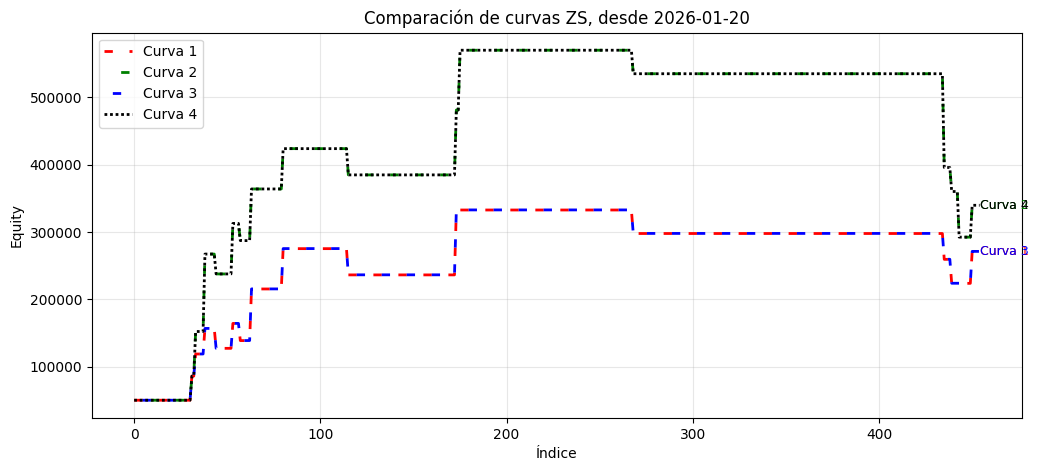

In [130]:
fig, ax = plt.subplots(figsize=(12, 5))

curvas = [
    equity_c,
    equity_c_s,
    equity_c_si,
    equity_c_todo
]

labels = ["Curva 1", "Curva 2", "Curva 3", "Curva 4"]

# Estilos de línea tipo "dash pattern" como en el ejemplo
estilos = [
    (0, (3, 6)),   # estilo 1
    (3, (3, 6)),   # estilo 2
    (6, (3, 6)),   # estilo 3
    (0, (1, 1))    # estilo 4 (punteado fino)
]

colores = ["r", "g", "b", "k"]  # rojo, verde, azul, negro

for curva, label, estilo, color in zip(curvas, labels, estilos, colores):
    linea, = ax.plot(
        curva,
        color=color,
        linestyle=estilo,
        linewidth=2,
        label=label
    )

    # Tag al final de la curva
    ax.text(
        x=len(curva)-1,
        y=curva[-1],
        s=label,
        fontsize=9,
        va='center',
        ha='left',
        color=color
    )

ax.set_title(f"Comparación de curvas {ASSET}, desde {start}")
ax.set_xlabel("Índice")
ax.set_ylabel("Equity")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()


In [131]:
# 1. Crear el DataFrame
df = pd.DataFrame({
    "equity_c": equity_c,
    "equity_c_s": equity_c_s,
    "equity_c_si": equity_c_si,
    "equity_c_todo": equity_c_todo
}).astype(float)

# 2. Seleccionar la columna con mayor equity final
best_col = df.iloc[-1].idxmax()

profit = df.iloc[-1].max() - specs[ASSET]["initial_margin"]*10

print("Mejor ganancia:", profit)

equity = df[best_col]

print("Mejor equity:", best_col)

# 3. Calcular MDD
rolling_max = equity.cummax()
drawdown = (rolling_max - equity) / rolling_max
max_dd = drawdown.max()

dd_usd = (rolling_max - equity).max()
eps = 1e-9
ratio = profit / max(dd_usd, eps)
print("Max Drawdown:", dd_usd)

print("Ratio:", ratio)

Mejor ganancia: 289774.9999999907
Mejor equity: equity_c_s
Max Drawdown: 277850.00000000186
Ratio: 1.042918841101273


In [132]:
# equity = pd.Series(equity_c)
equity = equity.dropna()
returns = equity.pct_change().dropna()
vol_daily = returns.std()
vol_annual = vol_daily * np.sqrt(252)
total_return = equity.iloc[-1] / equity.iloc[0] - 1
months = len(equity) / 21  # aprox 21 días de trading por mes
cagr = (1 + total_return)**(12 / months) - 1
sharpe = cagr / vol_annual

rolling_max = equity.cummax()
drawdown = (rolling_max - equity) / rolling_max
max_dd = drawdown.max()

In [133]:
dict_trades ={
    "equity_c": trades_c,
    "equity_c_s": trades_c_s,
    "equity_c_si": trades_c_si,
    "equity_c_todo": trades_c_todo
}

In [134]:
import pandas as pd

trades_df = pd.DataFrame(dict_trades[best_col])
trades_df["datetime_exit"] = pd.to_datetime(trades_df["datetime_exit"])
trades_df = trades_df.sort_values("datetime_exit").reset_index(drop=True)
trades_df["week"] = trades_df["datetime_exit"].dt.isocalendar().week
trades_df["year"] = trades_df["datetime_exit"].dt.isocalendar().year
weekly = trades_df.groupby(["year", "week"])["pnl_usd"].sum().reset_index()
trades_df["date"] = trades_df["datetime_exit"].dt.date
daily = trades_df.groupby("date")["pnl_usd"].sum().reset_index()
# weekly_pnl = weekly["pnl_usd"].values
weekly_pnl = daily["pnl_usd"].values

blocks, block_size = build_overlapping_blocks(weekly_pnl, block_size=1)
print("block_size usado:", block_size)
print("n_blocks:", len(blocks))

mc = monte_carlo_blocks(blocks, len(weekly_pnl), n_sims=5000)


block_size usado: 1
n_blocks: 14


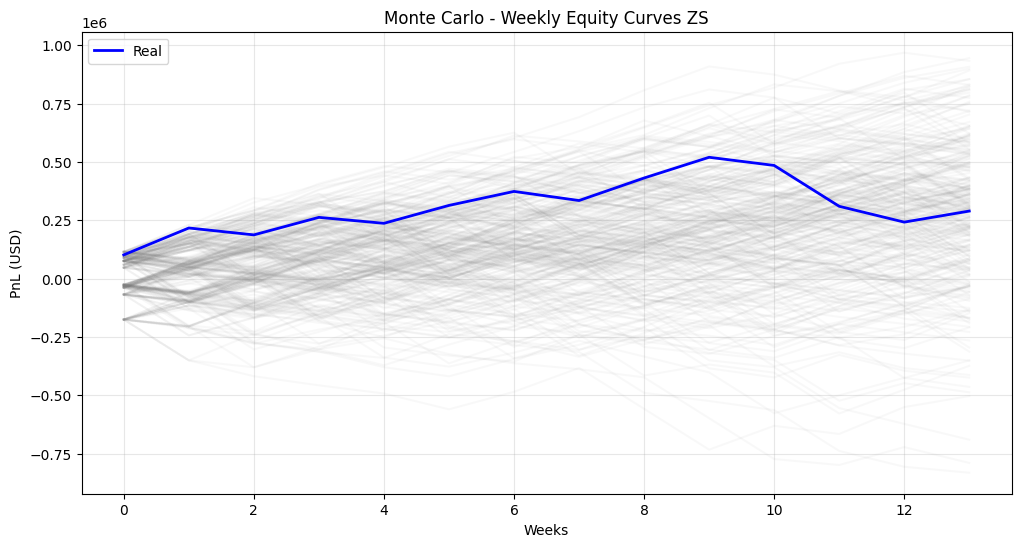

In [135]:

# equity real
real_equity = weekly_pnl.cumsum()

# equity simulada
mc_equity = mc.cumsum(axis=1)

plt.figure(figsize=(12,6))

# muchas curvas simuladas
for i in range(300):   # 300 para no saturar
    plt.plot(mc_equity[i], color="gray", alpha=0.05)

# curva real
plt.plot(real_equity, color="blue", linewidth=2, label="Real")

plt.title(f"Monte Carlo - Weekly Equity Curves {ASSET}")
plt.xlabel("Weeks")
plt.ylabel("PnL (USD)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [136]:
initial_capital = 1_000_000
pnl_cumsum = np.cumsum(mc, axis=1)  # shape (5000, 16)
equity_curves = initial_capital + pnl_cumsum

# Percentiles en cada punto temporal
p5  = np.percentile(equity_curves, 5,  axis=0)
p25 = np.percentile(equity_curves, 25, axis=0)
p50 = np.percentile(equity_curves, 50, axis=0)
p75 = np.percentile(equity_curves, 75, axis=0)
p95 = np.percentile(equity_curves, 95, axis=0)

final_equity = equity_curves[:, -1]  # shape (5000,)

pct_positive = (final_equity > initial_capital).mean() * 100
expected_final = final_equity.mean()
worst_case  = np.percentile(final_equity, 5)   # VaR al 95%
best_case   = np.percentile(final_equity, 95)
median_final = np.median(final_equity)

In [144]:
def max_drawdown(equity_row):
    peak = np.maximum.accumulate(equity_row)
    dd = (equity_row - peak) / peak
    return dd.min()

mdd_per_sim = np.array([max_drawdown(eq) for eq in equity_curves])

print(f"Median MDD : {np.median(mdd_per_sim):.1%}")
print(f"Worst MDD (p5): {np.percentile(mdd_per_sim, 5):.1%}")

Median MDD : -15.5%
Worst MDD (p95): -40.2%


In [139]:
def max_losing_streak(pnl_row):
    streak = max_streak = 0
    for p in pnl_row:
        streak = streak + 1 if p < 0 else 0
        max_streak = max(max_streak, streak)
    return max_streak

streaks = np.array([max_losing_streak(row) for row in mc])
print(f"Racha perdedora mediana: {np.median(streaks):.0f} trades")
print(f"Racha perdedora p95:     {np.percentile(streaks, 95):.0f} trades")

Racha perdedora mediana: 2 trades
Racha perdedora p95:     5 trades


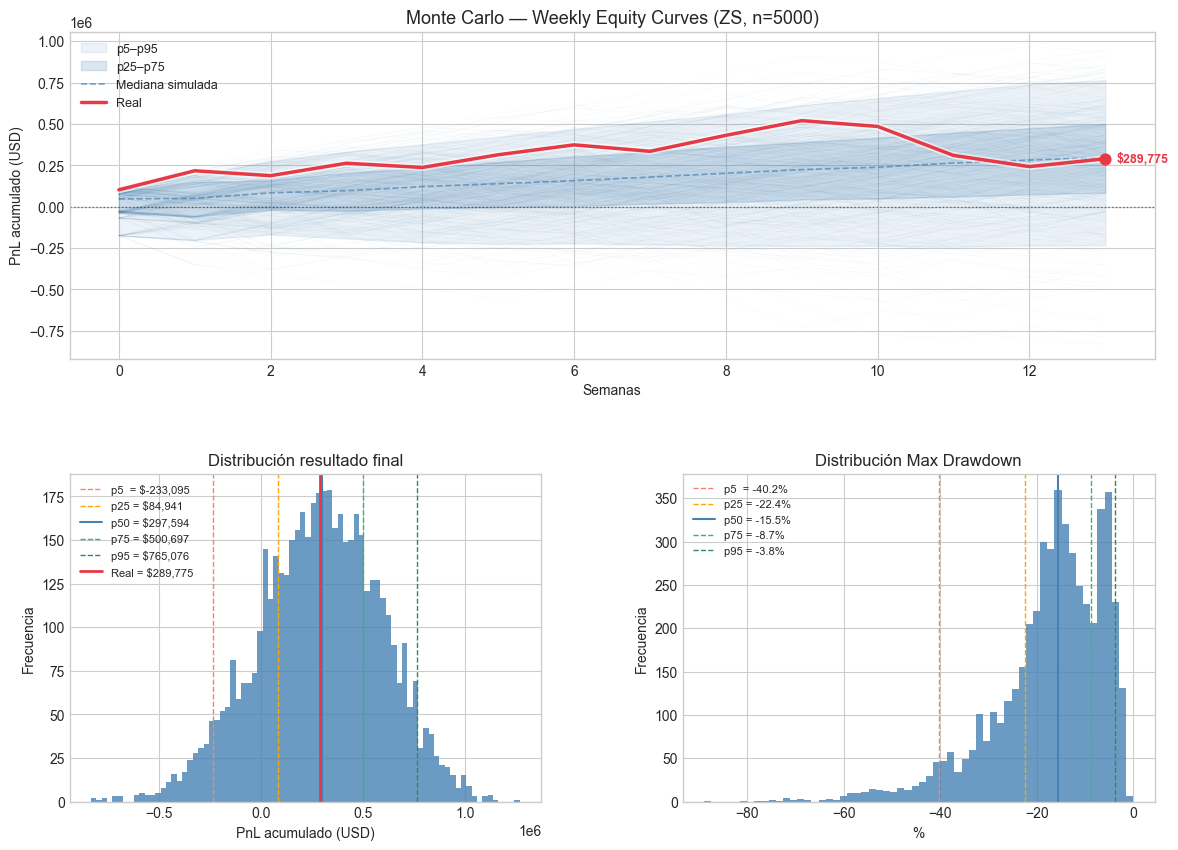

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

# ── Datos ──────────────────────────────────────────────────────────────────────
real_equity = weekly_pnl.cumsum()
mc_equity   = mc.cumsum(axis=1)
x = range(mc_equity.shape[1])

# Percentiles temporales (para el abanico)
p5  = np.percentile(mc_equity, 5,  axis=0)
p25 = np.percentile(mc_equity, 25, axis=0)
p50 = np.percentile(mc_equity, 50, axis=0)
p75 = np.percentile(mc_equity, 75, axis=0)
p95 = np.percentile(mc_equity, 95, axis=0)

# Percentiles del resultado final
final_equity = mc_equity[:, -1]
fe_p5,  fe_p25  = np.percentile(final_equity, [5,  25])
fe_p50, fe_p75  = np.percentile(final_equity, [50, 75])
fe_p95          = np.percentile(final_equity, 95)

# Percentiles del MDD
mdd_pct = mdd_per_sim * 100
mdd_p5,  mdd_p25  = np.percentile(mdd_pct, [5,  25])
mdd_p50, mdd_p75  = np.percentile(mdd_pct, [50, 75])
mdd_p95           = np.percentile(mdd_pct, 95)

# ── Layout 2×2: fila superior ocupa las dos columnas ──────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

ax_mc   = fig.add_subplot(gs[0, :])   # fila 0, todas las columnas
ax_fe   = fig.add_subplot(gs[1, 0])   # fila 1, columna 0
ax_mdd  = fig.add_subplot(gs[1, 1])   # fila 1, columna 1

# ── Panel superior: Equity curves ─────────────────────────────────────────────
for i in range(300):
    ax_mc.plot(x, mc_equity[i], color='steelblue', alpha=0.04, lw=0.5)

ax_mc.fill_between(x, p5,  p95,  alpha=0.10, color='steelblue', label='p5–p95')
ax_mc.fill_between(x, p25, p75,  alpha=0.20, color='steelblue', label='p25–p75')
ax_mc.plot(x, p50, color='steelblue', lw=1.2, ls='--', alpha=0.7, label='Mediana simulada')

# halo blanco + curva real encima
ax_mc.plot(x, real_equity, color='white',   lw=5,   zorder=4, alpha=0.6)
ax_mc.plot(x, real_equity, color='#e63946', lw=2.5, zorder=5, label='Real')

# punto y anotación al final
final_val = real_equity.iloc[-1] if hasattr(real_equity, 'iloc') else real_equity[-1]
ax_mc.scatter(x[-1], final_val, color='#e63946', zorder=6, s=60)
ax_mc.annotate(f'${final_val:,.0f}',
               xy=(x[-1], final_val),
               xytext=(8, 0), textcoords='offset points',
               va='center', color='#e63946', fontsize=9, fontweight='bold')

ax_mc.axhline(0, color='black', ls=':', lw=1, alpha=0.5)
ax_mc.set_title(f'Monte Carlo — Weekly Equity Curves ({ASSET}, n={len(mc_equity)})', fontsize=13)
ax_mc.set_xlabel('Semanas')
ax_mc.set_ylabel('PnL acumulado (USD)')
ax_mc.legend(fontsize=9)

# ── Panel inferior izquierdo: Distribución resultado final ────────────────────
ax_fe.hist(final_equity, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
ax_fe.axvline(fe_p5,  color='salmon',          ls='--', lw=1,   label=f'p5  = ${fe_p5:,.0f}')
ax_fe.axvline(fe_p25, color='orange',          ls='--', lw=1,   label=f'p25 = ${fe_p25:,.0f}')
ax_fe.axvline(fe_p50, color='steelblue',       ls='-',  lw=1.5, label=f'p50 = ${fe_p50:,.0f}')
ax_fe.axvline(fe_p75, color='mediumseagreen',  ls='--', lw=1,   label=f'p75 = ${fe_p75:,.0f}')
ax_fe.axvline(fe_p95, color='seagreen',        ls='--', lw=1,   label=f'p95 = ${fe_p95:,.0f}')
ax_fe.axvline(final_val, color='#e63946',      ls='-',  lw=2,   label=f'Real = ${final_val:,.0f}')
ax_fe.set_title('Distribución resultado final')
ax_fe.set_xlabel('PnL acumulado (USD)')
ax_fe.set_ylabel('Frecuencia')
ax_fe.legend(fontsize=8)

# ── Panel inferior derecho: Distribución Max Drawdown ─────────────────────────
ax_mdd.hist(mdd_pct, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
ax_mdd.axvline(mdd_p5,  color='salmon',         ls='--', lw=1,   label=f'p5  = {mdd_p5:.1f}%')
ax_mdd.axvline(mdd_p25, color='orange',         ls='--', lw=1,   label=f'p25 = {mdd_p25:.1f}%')
ax_mdd.axvline(mdd_p50, color='steelblue',      ls='-',  lw=1.5, label=f'p50 = {mdd_p50:.1f}%')
ax_mdd.axvline(mdd_p75, color='mediumseagreen', ls='--', lw=1,   label=f'p75 = {mdd_p75:.1f}%')
ax_mdd.axvline(mdd_p95, color='seagreen',       ls='--', lw=1,   label=f'p95 = {mdd_p95:.1f}%')
ax_mdd.set_title('Distribución Max Drawdown')
ax_mdd.set_xlabel('%')
ax_mdd.set_ylabel('Frecuencia')
ax_mdd.legend(fontsize=8)

# plt.savefig('monte_carlo.pdf', dpi=150, bbox_inches='tight')
plt.show()